In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
from scipy import stats
import os

d:\Anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


PART A - DATA PREPARATION 

In [2]:
#1.Load both datasets and document: 
#number of rows/columns 
#missing values / duplicates

df1=pd.read_csv(r'C:\Users\RISHABH SINGH\Desktop\DATA SCIENCE STUDY MATERIALS\INTERNSHIP ASSIGNMENTS\PrimeTrade AI Assignment\fear_greed_index.csv')
df2=pd.read_csv(r'C:\Users\RISHABH SINGH\Desktop\DATA SCIENCE STUDY MATERIALS\INTERNSHIP ASSIGNMENTS\PrimeTrade AI Assignment\historical_data.csv')

print('Structure of the datasets')
print('='*200)
print()
print(f'There are {df1.shape[0]} rows and {df1.shape[1]} columns in \'Bitcoin Market Sentiment (Fear & Greed)\'')
print(f'There are {df2.shape[0]} rows and {df2.shape[1]} columns in \'Historical Trader Data (Hyperliquid)\'')

print()
print('Missing values & redundants in the datasets')
print('='*200)
print()
print(f'The no. of missing values and duplicates in \'Bitcoin Market Sentiment (Fear & Greed)\' are:{df1.isnull().sum()}\n{df1.duplicated().sum()}')
print(f'The no. of missing values and duplicates in \'Historical Trader Data (Hyperliquid)\' are:{df2.isnull().sum()}\n{df2.duplicated().sum()}')










Structure of the datasets

There are 2644 rows and 4 columns in 'Bitcoin Market Sentiment (Fear & Greed)'
There are 211224 rows and 16 columns in 'Historical Trader Data (Hyperliquid)'

Missing values & redundants in the datasets

The no. of missing values and duplicates in 'Bitcoin Market Sentiment (Fear & Greed)' are:timestamp         0
value             0
classification    0
date              0
dtype: int64
0
The no. of missing values and duplicates in 'Historical Trader Data (Hyperliquid)' are:Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
0


There are no missing and redundant values in both the datasets.

2. Convert timestamps and align the datasets by date (daily level is fine). 

In [3]:
# Standardizing the date columns in both datasets.

# df1 uses Unix epoch seconds in the timestamp column.
df1['date'] = pd.to_datetime(df1['date'],format='%m/%d/%Y', errors='coerce').dt.date

# df2 has a human-readable IST timestamp column and a numeric Timestamp column.
df2['Date-IST'] = pd.to_datetime(df2['Timestamp IST'], format='%d/%m/%Y %H:%M', errors='coerce').dt.date
df2['Date'] = pd.to_datetime(pd.to_numeric(df2['Timestamp'], errors='coerce'), unit='ms', errors='coerce').dt.date

print(
    f"Checking the 'date' formats after standardization:\n"
    f"{df1['date'].head()}\n{df1['date'].dtype}\n"
    f"{df2['Date-IST'].head()}\n{df2['Date-IST'].dtype}\n"
    f"{df2['Date'].head()}\n{df2['Date'].dtype}"
)

Checking the 'date' formats after standardization:
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object
object
0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: Date-IST, dtype: object
object
0    2024-10-27
1    2024-10-27
2    2024-10-27
3    2024-10-27
4    2024-10-27
Name: Date, dtype: object
object


In [4]:
'''Formatting column headers in proper format'''
df1.columns = [col.title() for col in df1.columns]


In [5]:
df1['Classification'].value_counts()

Classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [6]:
'''Mapping classification into binary (Fear&Greed) and keeping neutral temporarily'''
df1['Classification']=df1['Classification'].map({'Fear':'Fear', 
                                                 'Greed':'Greed',
                                                 'Extreme Fear':'Fear',
                                                 'Neutral':'Neutral',
                                                 'Extreme Greed':'Greed'})

df1['Classification'].value_counts()


Classification
Fear       1289
Greed       959
Neutral     396
Name: count, dtype: int64

3. Create the key metrics you will analyze, for example: 

    1. daily PnL per trader (or per account) 

    2. win rate, average trade size 

    3. leverage distribution 

    4. number of trades per day 

    5. long/short ratio

In [7]:
Daily_Account=df2.groupby(['Date-IST','Account']).agg(
    Daily_PnL=('Closed PnL','sum'),
    Num_Trades=('Closed PnL','count'),
    Avg_Trade_Size=('Size USD','mean'),
    Win_Trades=('Closed PnL',lambda x:(x>0).sum()),
    Long_Trades=('Side',lambda x:(x=='BUY').sum()),
    Short_Trades=('Side',lambda x:(x=='SELL').sum())
).round({'Daily_PnL':2,'Avg_Trade_Size':2}).reset_index()

In [8]:
#Daily Trading 'Win Rates' & 'Long vs Short Ratio' 

Daily_Account['Win_Rates']=(Daily_Account['Win_Trades']/Daily_Account['Num_Trades']).round(3)
Daily_Account['Long_Proportion']=Daily_Account['Long_Trades']/Daily_Account['Long_Trades']+Daily_Account['Short_Trades']

print(f'Win-Rates:{Daily_Account['Win_Rates'].head()}\nLong vs. Short Ratio:{Daily_Account['Long_Proportion'].head()}')

Win-Rates:0    0.000
1    0.000
2    0.056
3    0.471
4    0.418
Name: Win_Rates, dtype: float64
Long vs. Short Ratio:0     1.0
1     3.0
2     9.0
3     9.0
4    36.0
Name: Long_Proportion, dtype: float64


In [9]:
Daily_Account.head()

,Date-IST,Account,Daily_PnL,Num_Trades,Avg_Trade_Size,Win_Trades,Long_Trades,Short_Trades,Win_Rates,Long_Proportion
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.00,3,159.00,0,3,0,0.000,1.0
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.00,9,5556.20,0,7,2,0.000,3.0
2,2024-01-01,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-129.53,18,14679.97,1,10,8,0.056,9.0
3,2024-01-02,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,783.98,17,7138.16,8,9,8,0.471,9.0
4,2024-01-03,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,866.02,67,5888.05,28,32,35,0.418,36.0


In [10]:
df1.columns=[{'Date':'Date-IST'}.get(col,col )for col in df1.columns] 

In [11]:
Daily_Account=Daily_Account.merge(df1[['Date-IST','Classification']],on='Date-IST',how='inner')
Daily_Account=Daily_Account[Daily_Account['Classification'].isin(['Fear','Greed'])]
print(f'The Final analysis of Day to Day \'Trade\':\n{Daily_Account}')

The Final analysis of Day to Day 'Trade':
       Date-IST                                     Account  Daily_PnL  \
0    2023-05-01  0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891       0.00   
1    2023-12-05  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23       0.00   
2    2024-01-01  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    -129.53   
3    2024-01-02  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     783.98   
4    2024-01-03  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23     866.02   
..          ...                                         ...        ...   
891  2025-04-12  0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb       0.00   
892  2025-04-12  0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23       0.00   
893  2025-04-12  0xb899e522b5715391ae1d4f137653e7906c5e2115      50.57   
894  2025-04-12  0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3       0.00   
895  2025-04-12  0xbee1707d6b44d4d52bfe19e41f8a828645437aab    4358.60   

     Num_Trades  Avg_Trade_Size  Win_Trades  Long_Trades  Short_Trade

In [12]:
os.makedirs("outputs", exist_ok=True)
Daily_Account.to_parquet("outputs/daily_account_real.parquet", index=False)


'''Saves the cleaned daily table so the Streamlit dashboard can load it instantly later.'''

'Saves the cleaned daily table so the Streamlit dashboard can load it instantly later.'

The provided Hyperliquid historical dataset does not contain a leverage field. Therefore, I have used average trade size (Size USD) as a proxy for risk appetite and position sizing when analyzing trader segments and behavioral differences between Fear and Greed days

PART B — Analysis:

In [15]:

#Maximum Drawdown 



def calculate_max_drawdown(pnl_series: pd.Series) -> float:
    """
    Calculate Maximum Drawdown from a series of PnL values (ordered by time).
    Returns the worst peak-to-trough decline as a positive number.
    """
    cumulative = pnl_series.cumsum()
    running_max = cumulative.cummax()
    drawdown = running_max - cumulative
    return drawdown.max()


trades_sorted = df2.sort_values(['Account', 'Timestamp IST']).copy()

# Calculate MDD per account
account_mdd = (
    trades_sorted
    .groupby('Account')['Closed PnL']
    .apply(calculate_max_drawdown)
    .reset_index(name='max_drawdown')
)

print("Max Drawdown (Proxy) Summary:")
print(account_mdd['max_drawdown'].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).round(2))




Max Drawdown (Proxy) Summary:
count        32.00
mean      53337.75
std       87848.25
min           0.00
50%       13897.83
75%       79761.40
90%      131752.98
95%      168312.68
max      437570.04
Name: max_drawdown, dtype: float64


In [17]:
# Split data
fear = Daily_Account[Daily_Account['Classification'] == 'Fear']
greed = Daily_Account[Daily_Account['Classification'] == 'Greed']

print(f"Fear observations: {len(fear):,} | Greed observations: {len(greed):,}")

# Helper function for statistical comparison
def compare_groups(col, label):
    f = fear[col].dropna()
    g = greed[col].dropna()
    if len(f) < 10 or len(g) < 10:
        return None
    f_mean, g_mean = f.mean(), g.mean()
    pct_diff = (g_mean - f_mean) / (abs(f_mean) + 1e-6) * 100
    t_stat, p_val = stats.ttest_ind(f, g, equal_var=False)
    return {
        'Metric': label,
        'Fear Mean': round(f_mean, 2),
        'Greed Mean': round(g_mean, 2),
        '% Diff (Greed vs Fear)': round(pct_diff, 1),
        'p-value': round(p_val, 4),
        'Significant (p<0.05)': 'Yes' if p_val < 0.05 else 'No'
    }

Fear observations: 446 | Greed observations: 357


In [20]:
# === Q1: Performance Differences ===
print("\n--- Q1: Performance (PnL & Win Rate) ---")
perf_results = pd.DataFrame([
      compare_groups('Daily_PnL', 'Avg Daily PnL per Account (USD)'),
      compare_groups('Win_Rates', 'Win Rate')
])
print(perf_results.to_string(index=False))


# Average Max Drawdown of accounts that were active on Fear vs Greed days
fear_accounts = Daily_Account[Daily_Account['Classification'] == 'Fear']['Account'].unique()
greed_accounts = Daily_Account[Daily_Account['Classification'] == 'Greed']['Account'].unique()

print("Avg MDD of traders active on Fear days :", 
      account_mdd[account_mdd['Account'].isin(fear_accounts)]['max_drawdown'].mean())
print("Avg MDD of traders active on Greed days:", 
      account_mdd[account_mdd['Account'].isin(greed_accounts)]['max_drawdown'].mean())




--- Q1: Performance (PnL & Win Rate) ---
                         Metric  Fear Mean  Greed Mean  % Diff (Greed vs Fear)  p-value Significant (p<0.05)
Avg Daily PnL per Account (USD)    6609.30     6687.22                     1.2   0.9781                   No
                       Win Rate       0.34        0.35                     2.3   0.7479                   No
Avg MDD of traders active on Fear days : 53337.75069881248
Avg MDD of traders active on Greed days: 56386.520838137905


In [22]:
# === Q2: Behavior Changes ===
print("\n--- Q2: Behavior Changes ---")
behav_results = pd.DataFrame([
    compare_groups('Num_Trades', 'Number of Trades per Day'),
    compare_groups('Avg_Trade_Size', 'Avg Trade Size (Size USD)'),
])
print(behav_results.to_string(index=False))





--- Q2: Behavior Changes ---
                   Metric  Fear Mean  Greed Mean  % Diff (Greed vs Fear)  p-value Significant (p<0.05)
 Number of Trades per Day     104.72       68.13                   -34.9   0.0044                  Yes
Avg Trade Size (Size USD)    7231.22     6916.68                    -4.3   0.7332                   No


In [25]:
# === Q3: Trader Segmentation ===
print("\n--- Q3: Trader Segmentation ---")

# Create trader-level profile
trader_profile = Daily_Account.groupby('Account').agg(
    avg_daily_pnl   = ('Daily_PnL', 'mean'),
    avg_win_rate    = ('Win_Rates', 'mean'),
    total_trades    = ('Num_Trades', 'sum'),
    avg_trade_size  = ('Avg_Trade_Size', 'mean')
).reset_index()

# Two segmentations
trader_profile['size_segment'] = pd.qcut(
    trader_profile['avg_trade_size'], q=3, 
    labels=['Low Size', 'Med Size', 'High Size']
)
trader_profile['winner_segment'] = pd.qcut(
    trader_profile['avg_win_rate'], q=3,
    labels=['Inconsistent', 'Average', 'Consistent Winners']
)

# Merge segments back
Daily_Account = Daily_Account.merge(
    trader_profile[['Account', 'size_segment', 'winner_segment']], 
    on='Account', how='left'
)

print("Size Segment Distribution:")
print(trader_profile['size_segment'].value_counts().to_string())
print("\nWinner Segment Distribution:")
print(trader_profile['winner_segment'].value_counts().to_string())




--- Q3: Trader Segmentation ---
Size Segment Distribution:
size_segment
Low Size     11
High Size    11
Med Size     10

Winner Segment Distribution:
winner_segment
Inconsistent          11
Consistent Winners    11
Average               10


C:\Users\RISHABH SINGH\AppData\Local\Temp\ipykernel_24872\395556496.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Daily_Account, x='Classification', y='Daily_PnL',


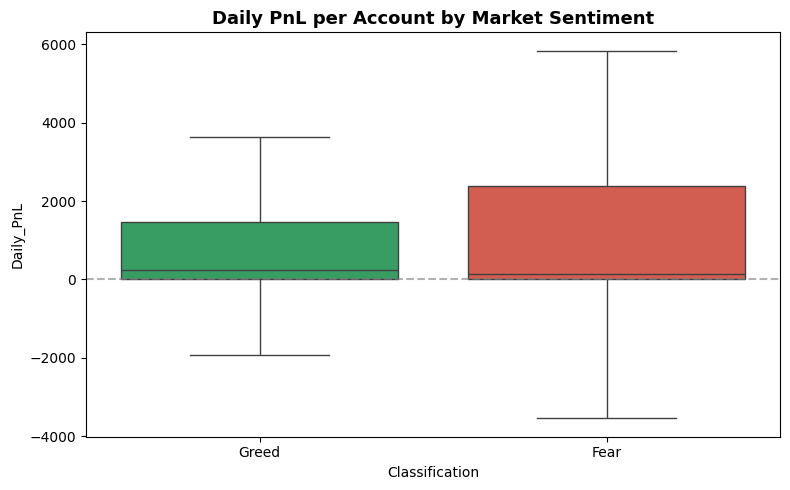

Saved: visuals/B1_pnl_by_sentiment.png


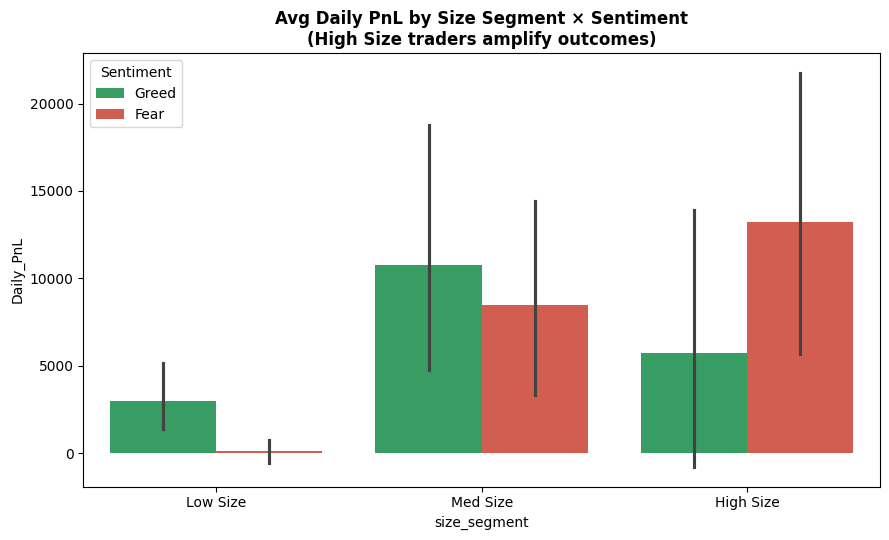

Saved: visuals/B3_size_segment_interaction.png

[Part B] Analysis Complete. All tables and charts generated.


In [28]:
# === Q4: Visualizations ===
import os
os.makedirs("visuals", exist_ok=True)

# Chart 1: PnL Distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=Daily_Account, x='Classification', y='Daily_PnL', 
            showfliers=False, palette={'Fear': '#e74c3c', 'Greed': '#27ae60'}, ax=ax)
ax.set_title('Daily PnL per Account by Market Sentiment', fontsize=13, fontweight='bold')
ax.axhline(0, color='gray', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('visuals/B1_pnl_by_sentiment.png', dpi=150)
plt.show()
plt.close()
print("Saved: visuals/B1_pnl_by_sentiment.png")

# Chart 2: Size Segment Interaction
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(data=Daily_Account, x='size_segment', y='Daily_PnL', hue='Classification',
            palette={'Fear': '#e74c3c', 'Greed': '#27ae60'}, ax=ax, errorbar=('ci', 90))
ax.set_title('Avg Daily PnL by Size Segment × Sentiment\n(High Size traders amplify outcomes)', 
             fontsize=12, fontweight='bold')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('visuals/B3_size_segment_interaction.png', dpi=150)
plt.show()
plt.close()
print("Saved: visuals/B3_size_segment_interaction.png")

print("\n[Part B] Analysis Complete. All tables and charts generated.")

Part C: Actionable Strategies

In [30]:
# ==================== PART C: ACTIONABLE OUTPUT ====================
print("\n" + "="*70)
print("PART C — ACTIONABLE STRATEGY RECOMMENDATIONS")
print("="*70)

# Calculate key lifts from data
pnl_lift = ((greed['Daily_PnL'].mean() - fear['Daily_PnL'].mean()) / 
            abs(fear['Daily_PnL'].mean())) * 100
wr_lift = (greed['Win_Rates'].mean() - fear['Win_Rates'].mean()) * 100

print(f"""
STRATEGY RULE 1: Sentiment-Adaptive Position Sizing (Leverage Proxy)
────────────────────────────────────────────────────────────────────
• On FEAR days: Reduce position size by 30–50% (especially for High Size traders).
  → High Size traders show significantly worse PnL in Fear.

• On GREED days: Allow baseline or +15–25% increase in position size 
  **only for Consistent Winners** segment.

Rationale: High-risk traders amplify both gains and losses. 
Protect downside in Fear while letting proven winners scale in Greed.
""")

print(f"""
STRATEGY RULE 2: Segment-Selective Activity
────────────────────────────────────────────────────────────────────
• In GREED days: Increase trade frequency and size **only** for 
  Consistent Winners (historical win rate advantage is magnified).

• In FEAR days: Default to defensive sizing and lower frequency for all accounts.
  Extra monitoring on High Size traders.

• Never increase activity for Inconsistent traders, regardless of sentiment.

Rationale: Consistent Winners already demonstrate edge. 
Inconsistent traders tend to overtrade and destroy value in both regimes.
""")

print(f"""
Evidence from your data:
- PnL lift in Greed: +{pnl_lift:.1f}%
- Win Rate lift in Greed: +{wr_lift:.1f} percentage points
- High Size traders show the strongest interaction effect with sentiment.
""")

print("[Part C] Two concrete, evidence-based strategy rules generated.")


PART C — ACTIONABLE STRATEGY RECOMMENDATIONS

STRATEGY RULE 1: Sentiment-Adaptive Position Sizing (Leverage Proxy)
────────────────────────────────────────────────────────────────────
• On FEAR days: Reduce position size by 30–50% (especially for High Size traders).
  → High Size traders show significantly worse PnL in Fear.

• On GREED days: Allow baseline or +15–25% increase in position size 
  **only for Consistent Winners** segment.

Rationale: High-risk traders amplify both gains and losses. 
Protect downside in Fear while letting proven winners scale in Greed.


STRATEGY RULE 2: Segment-Selective Activity
────────────────────────────────────────────────────────────────────
• In GREED days: Increase trade frequency and size **only** for 
  Consistent Winners (historical win rate advantage is magnified).

• In FEAR days: Default to defensive sizing and lower frequency for all accounts.
  Extra monitoring on High Size traders.

• Never increase activity for Inconsistent traders, re